## **Imports & Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns',None)

## **Load Data**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/imadsaeed123/vehicle-sale-data/Vehicle Sales Data/archive/car_prices.csv')
print(df.shape)
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head()

(558837, 16)
Memory: 371.54 MB


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## **Basic INFO**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


## **Missing Values**

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) *100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df[missing_df['Missing'] > 0].sort_values('Percentage',ascending = False)

,Missing,Percentage
transmission,65352,11.694287
body,13195,2.361154
condition,11820,2.115107
trim,10651,1.905922
model,10399,1.860829
make,10301,1.843292
color,749,0.134028
interior,749,0.134028
odometer,94,0.016821
mmr,38,0.006800


## **Duplicates**

In [5]:
duplicates =df.duplicated().sum()
print(f"Duplicate rows:{duplicates} ({duplicates/len(df)*100:.2f}%)")

Duplicate rows:0 (0.00%)


## **Statistical Summary**

In [6]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


## **Checking Targeting Variables** 

Target: sellingprice
Mean: $13,611.36
Median: $12,100.00
Min: $1.00
Max: $230,000.00
Skewness: 1.953


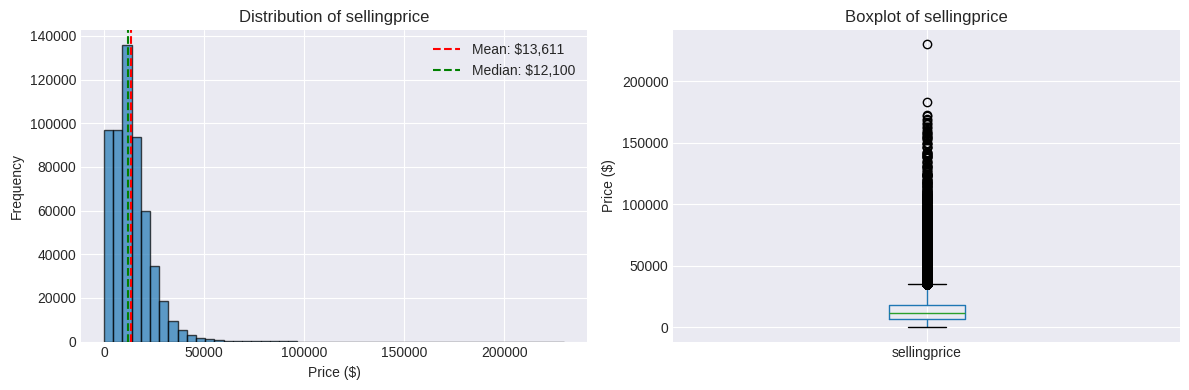

In [7]:
target_col = 'sellingprice'

print(f"Target: {target_col}")
print(f"Mean: ${df[target_col].mean():,.2f}")
print(f"Median: ${df[target_col].median():,.2f}")
print(f"Min: ${df[target_col].min():,.2f}")
print(f"Max: ${df[target_col].max():,.2f}")
print(f"Skewness: {df[target_col].skew():.3f}") # If a Mean is higher than a median tne skewness will be higher means its Asymetircs

# Quick distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df[target_col], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f'Mean: ${df[target_col].mean():,.0f}')
axes[0].axvline(df[target_col].median(), color='green', linestyle='--', label=f'Median: ${df[target_col].median():,.0f}')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {target_col}')
axes[0].legend()

# Boxplot
df.boxplot(column=target_col, ax=axes[1])
axes[1].set_title(f'Boxplot of {target_col}')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

## **Checking if Target is Skewed( For Regression Decision)**

In [8]:
skewness = df[target_col].skew()
if abs(skewness) > 1:
    print(f"\N{warning sign} Target is Highily Skewed ({skewness:.2f} - Consider log Transform")
else:
    print(f"\N{check mark}")

⚠ Target is Highily Skewed (1.95 - Consider log Transform


## **Correlation Matrix (Only Numeric)**

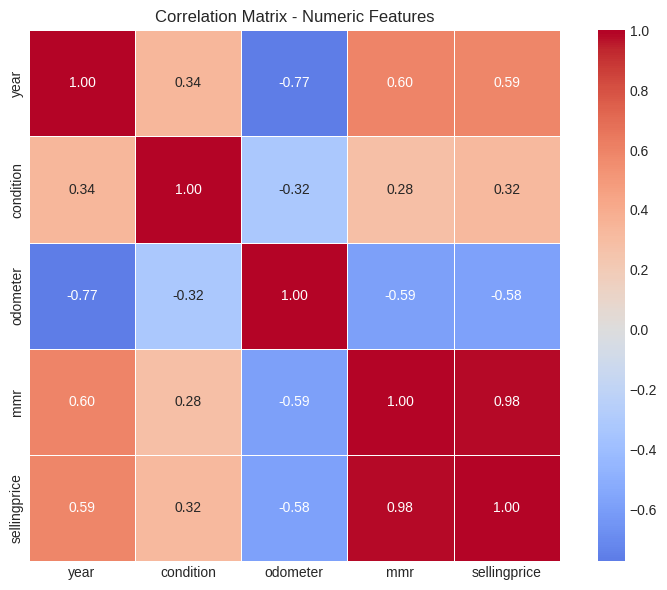


Correlation with sellingprice:
  mmr: 0.984
  year: 0.586
  condition: 0.322
  odometer: -0.582


In [9]:
numeric_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']

plt.figure(figsize=(8, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

# Show correlation with target
print("\nCorrelation with sellingprice:")
corr_with_target = corr_matrix['sellingprice'].sort_values(ascending=False)
for col, corr in corr_with_target.items():
    if col != 'sellingprice':
        print(f"  {col}: {corr:.3f}")

## **Check Categorical Columns**

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head())


make: 96 unique values
make
Ford         93554
Chevrolet    60197
Nissan       53946
Toyota       39871
Dodge        30710
Name: count, dtype: int64

model: 973 unique values
model
Altima    19349
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64

trim: 1963 unique values
trim
Base       55817
SE         43648
LX         20757
Limited    18367
LT         16915
Name: count, dtype: int64

body: 87 unique values
body
Sedan        199437
SUV          119292
sedan         41906
suv           24552
Hatchback     21380
Name: count, dtype: int64

transmission: 4 unique values
transmission
automatic    475915
manual        17544
sedan            15
Sedan            11
Name: count, dtype: int64

vin: 550297 unique values
vin
automatic            22
wbanv13588cz57827     5
wddgf56x78f009940     4
1ftfw1cv5afb30053     4
5uxfe43579l274932     4
Name: count, dtype: int64

state: 64 unique values
state
fl    82945
ca    73148
pa    53907
tx    45913
ga    347

 ## **Outlier Detection (IQR Method)**

In [11]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

year: 4021 outliers (0.7%)
odometer: 10375 outliers (1.9%)
mmr: 16315 outliers (2.9%)
sellingprice: 16354 outliers (2.9%)


## **Class Imbalance Check (For Classification Phase)**

In [12]:
# Checking if any categorical column is imbalanced
for col in categorical_cols:
    if df[col].nunique() <= 10:
        counts = df[col].value_counts()
        ratio = counts.iloc[0] / counts.iloc[-1]
        if ratio > 5:
            print(f"\N{warning sign} {col} is IMBALANCED (ratio: {ratio:.1f})")
        else:
            print(f" \N{check Mark} {col} is balanced (ratio: {ratio:.1f})")

⚠ transmission is IMBALANCED (ratio: 43265.0)


## **SUMMARY**

In [13]:
print("="*60)
print("EDA SUMMARY - VEHICLE SALES DATA")
print("="*60)

print("\nDATASET OVERVIEW:")
print(f"   • Total rows: {len(df):,}")
print(f"   • Total columns: {len(df.columns)}")
print(f"   • Memory usage: 371 MB")

print("\nTARGET VARIABLE (sellingprice):")
print(f"   • Range: $1 - $230,000")
print(f"   • Mean: $13,611 | Median: $12,100")
print(f"   • Skewness: 1.95 (HIGHLY SKEWED -> RIGHT)")
print(f"   • Outliers: 16,354 rows (2.9%)")

print("\nDATA QUALITY ISSUES:")
print(f"   • Missing values: YES (transmission: 11.7% missing)")
print(f"   • Duplicates: NONE")
print(f"   • Outliers detected in numeric columns")

print("\nFEATURE INSIGHTS:")
print(f"   • Best predictor: mmr (correlation: 0.984 with sellingprice)")
print(f"   • High cardinality categoricals:")
print(f"     - model: 973 unique values")
print(f"     - trim: 1,963 unique values")
print(f"     - seller: 14,263 unique values")
print(f"     - vin: 550,297 unique values (IDENTIFIER - DROP)")

print("\nCLASS IMBALANCE (For Classification Phase):")
print(f"   • transmission: HIGHLY IMBALANCED")
print(f"     - automatic: 475,915 (96.4%)")
print(f"     - manual: 17,544 (3.6%)")
print(f"     -> Ratio: 27:1")

print("\n" + "="*60)
print("RECOMMENDATIONS FOR MODELING")
print("="*60)

print("\nFOR REGRESSION PHASE:")
print("   1. Target transformation: Use np.log1p(sellingprice)")
print("   2. Remove VIN column (unique identifier)")
print("   3. Handle missing values in transmission (mode or drop)")
print("   4. Features to use: mmr, year, odometer, condition, make, model, body, state")
print("   5. Consider capping outliers at 99th percentile")

print("\nFOR CLASSIFICATION PHASE (After Regression):")
print("   1. Convert sellingprice into classes:")
print("      - Binary: 'High' (>$12,100) vs 'Low' (<= $12,100)")
print("      - Multi-class: 'Low' (<$6,900), 'Medium' ($6,900-$18,200), 'High' (>$18,200)")
print("   2. Handle transmission imbalance (class weights or SMOTE)")
print("   3. Drop VIN (not useful for classification either)")

print("\nCOLUMNS TO DROP IMMEDIATELY:")
print("   • vin (550k unique values - useless for prediction)")
print("   • saledate (unless you extract features like month/day)")


EDA SUMMARY - VEHICLE SALES DATA

DATASET OVERVIEW:
   • Total rows: 558,837
   • Total columns: 16
   • Memory usage: 371 MB

TARGET VARIABLE (sellingprice):
   • Range: $1 - $230,000
   • Mean: $13,611 | Median: $12,100
   • Skewness: 1.95 (HIGHLY SKEWED -> RIGHT)
   • Outliers: 16,354 rows (2.9%)

DATA QUALITY ISSUES:
   • Missing values: YES (transmission: 11.7% missing)
   • Duplicates: NONE
   • Outliers detected in numeric columns

FEATURE INSIGHTS:
   • Best predictor: mmr (correlation: 0.984 with sellingprice)
   • High cardinality categoricals:
     - model: 973 unique values
     - trim: 1,963 unique values
     - seller: 14,263 unique values
     - vin: 550,297 unique values (IDENTIFIER - DROP)

CLASS IMBALANCE (For Classification Phase):
   • transmission: HIGHLY IMBALANCED
     - automatic: 475,915 (96.4%)
     - manual: 17,544 (3.6%)
     -> Ratio: 27:1

RECOMMENDATIONS FOR MODELING

FOR REGRESSION PHASE:
   1. Target transformation: Use np.log1p(sellingprice)
   2. Remo